# Aula 8


# Autoencoders



### Eduardo Lobo Lustosa Cabral

## 1. Objetivos

Definir conceito de espaço latente.

Apresentar o que é um autoencoder.

Apresentar como criar autoencoders com o TensorFlow.

Criar um autoencoder com camadas densas.

Criar um autoencoder com camadas convolucionais.

### Importação das bilbiotecas necessárias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.__version__)

2.19.0


## 2. Introdução

Antes de iniciar a formulação dos modelos generativos de fato e mais precisamente nessa aula os Autoencoders, vamos relembrar o que são modelos generativos.

RNAs deep learning são capazes de produzir imagens, textos e músicas artificiais. Essa capacidade das RNAs têm muitas aplicações promissoras em negócios e arte.

Os principais tipos de modelos generativos baseados em RNAs:

1. Autoencoders variacionais (AEV)
2. Redes adversárias generativas (GANs)
3. Modelos capazes de prever o próximo dado em uma sequência
4. Modelos de difusão

Existem atualmente muitas aplicações de modelos generativos em pesquisa, negócios, artes e até disponibilizados para o público geral.

A longo prazo os modelos generativos consitem de uma grande promessa da IA para se tornarem sistemas automáticos que aprenderem sem supervisão características de um conjunto de dados, ou seja, eles tem o potencial de serem sistemas que aprendem por conta própria.

Observa-se que um autoencoder comum, como o que veremos nessa aula, não é de fato considerado um modelo generativo, mas eles  são capazes de gerar novos dados, porém de uma forma limitada.

Os modelos generativos construídos para prever o próximo dado em uma sequência são modelos utilizados para criar textos e músicas. Esses tipos de modelos servem para muitas outras tarefas além de criar novos textos ou músicas e são modelos "comuns" usados para processar esses tipos de dados. Esses tipos de modelos jáforam vistos em outras disciplinas.

Os modelos generativos baseados nos AEVs, GANs e modelos de difusão usam uma representação dos dados chamada de espaço latente (ou representação latente) para produzir novos dados. Assim, a primeira etapa para um modelo produzir novos dados é aprender o espaço latente do que é desejado gerar.

## 3. Espaço latente

A palavra “latente” significa “escondido”. Espaço latente é um termo muito usado em IA. Um espaço latente consiste de uma transformação dos dados originais, onde exemplos de dados semelhantes ficam "próximos" entre sí e exemplos de dados diferentes ficam "distantes".

Espaço latente se refere a um espaço multidimensional abstrato que contém valores de características de dados que não podemos interpretar diretamente, mas que codifica uma representação interna de eventos observados externamente.

Assim como as pessoas possuem compreensão de uma ampla gama de tópicos e dos eventos pertencentes a esses tópicos, o espaço latente visa fornecer uma compreensão semelhante para um computador por meio de uma representação quantitativa.

Uma RNA para realizar uma dada tarefa (classificação, regressão, reconstrução de imagem) primeiramente extrai caracteríticas dos dados usando suas diversas camadas. Dizemos que a função que mapeia a entrada para as camadas projeta os dados no espaço latente. Em outras palavras, o espaço latente é o espaço onde estão as características dos dados.

Uma das motivações para aprender um espaço latente de um certo tipo de dado é que grandes diferenças no espaço dos dados  podem ser ocasionadas por pequenas variações no espaço latente. Portanto, aprender um espaço latente ajuda um modelo a entender melhor os dados do que os próprios dados observados, que é um espaço muito grande para aprender.

Alguns exemplos de espaço latente são:

1) Embedding de palavras ("word embedding"): consiste em vetores que representam palavras, onde palavras semelhantes em significado são representadas por vetores que ficam próximos uns dos outros no espaço (conforme medido por exemplo pela distância euclidiana) e palavras que não estão relacionadas ficam distantes.

2) Espaço de caracteríticas de imagens: as camadas finais das redes convolucionais codificam características de alto nível que permitem detectar efetivamente o que uma imagem mostra, por exemplo, a presença de um gato em uma imagem em diferentes condições de iluminação e ângulos de observação, o que é uma tarefa difícil no espaço dos pixels da imagem.

3) Métodos de modelagem de tópicos (LDA, PLSA) capazes de extrair significados de textos, usam abordagens estatísticas para obter um conjunto latente de tópicos contidos em um conjunto de documentos. Na extração de significado de textos, o modelo produz um espaço latente de forma que documentos pertencentes a tópicos semelhantes fiquem mais próximos no espaço latente de tópicos.

Por exemplo, considere as 4 imagens da Figura 1.


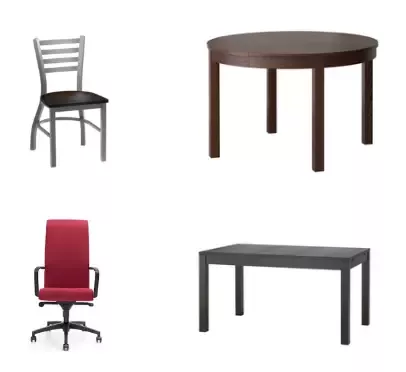
<center>Figura 1 - Exemplos de imagens de cadeiras e mesas.("Cadeira_mesa.png")</center>

No espaço de pixels que as pessoas enxergam, não há semelhança imediata entre as duas imagens de cadeiras e de mesas. No entanto, se essas imagens fossem mapeadas para um espaço latente, as imagens das cadeiras vão estar mais próximas entre elas do que entre as imagens de cadeiras e de mesas e o mesmo acontece com as imagens das mesas. O espaço latente captura a essência da estrutura dos dados para realizar uma dada tarefa.

Um espaço latente pode ter uma pequena ou uma grande dimensão em relação à dimensão dos dados originais. Os termos "grande dimensão" e "pequena dimensão" de um espaço latente ajuda a definir quão específicos ou gerais são os tipos de características que desejadas que o espaço latente aprenda e represente. Um espaço latente de grande dimensão é sensível a características mais específicas dos dados de entrada e às vezes pode levar ao sobreajuste quando não há dados de treinamento suficientes. Um espaço latente de pequena dimensão visa capturar as características mais importantes necessárias para aprender e representar os dados de entrada.

## 4. Autoencoders

Um autoencoder é uma RNA capaz de aprender representar dados sem supervisão, ou seja, realiza uma tarefa de aprendizado não supervisionado onde os dados de treinamento não são rotulados.

O conceito de um autoencoder é muito similar à ideia de compactação de informação. No caso de uma imagem, o autoencoder gera uma matriz (ou um vetor) capaz de representar a imagem original, sem muita perda de informação, com uma dimensão  menor do que a imagem original.

Os autoencoders podem ser usados para redução de dimensão de dados de forma a facilitar visualização. Por exemplo, dados de 4 dimensões podem ser reduzidos para 2 ou 3 dimensões, permitindo a sua vizualização e obviamente a sua compactação.

Os autoencoders podem ser usados para criar novos dados similares aos dados originais, permitindo gerar novos exemplos para serem usados, por exemplo, em treinamento supervisionado de RNAs.

Os autoencoders consistem de uma forma eficiente de representar dados. Um autoencoder reproduz os dados de entrada na sua saída e ao fazer isso aprende como representar os dados de entrada.

O objetivo de um autoencoder é criar uma representação latente dos dados. Usando essa representação latente é possível reconstruir os dados originais e/ou produzir novos exemplos de dados.

### 4.1 Aplicações de autoencoders

A remoção de ruído de dados e a redução de dimensionalidade para visualização de dados são as duas principais aplicações dos autoencoders. Nota-se que os autoencoders podem aprender projeções de dados melhor do que um PCA.

Alguns exemplos de aplicação de autoencoders são descritos a seguir.


#### Compactação de dados

Por exemplo, uma imagem de dimensão 256x256 pixels pode ser representada por 28x28 pixels. O Google está usando esse tipo codificação para permitir uma utilização mais otimizada dos sistemas de transmissão de dados. Nesse caso, somente a representação latente da imagem é transmitida e, em seguida, no telefone/computador do usuário o decodificador reconstrói a imagem.


#### Processamento de linguagem antural

No processamento natural de linguagem usando deep learning os autoencoders são usados com diversas finalidades.

- Codificação "embedding" de palavras, frases, ou contexto de uma palavra em um documento.

- Agrupamento (classificação) de documentos por categorias (assuntos). Hinton usou um autoencoder para reduzir os vetores "embedding" de forma a representar as probabilidades de palavras em notícias.

- Autoencoders são usados em sistemas de codificação de voz para criar espectrogramas se sinais de voz

- Autoencoders são usados para eliminação de ruído em sinais de voz aumentando o desempenho de sistemas de reconhecimento automático de fala.

- É comum ter duas frases que parecem ser diferentes, mas ambas têm o mesmo significado. Autoencoders são usados para detectar essas frases com precisão.


#### Processamento de imagens

Autoencoders tem muitas aplicações em processamento de imagens. Por exemplo, são usados na reconstrução de imagens com partes ausentes, para eliminar ruído de imagens, para alterar a coloração de imagens e gerar imagens de alta resolução.


#### Autoencoder para detecção de anomalias em vídeo

A detecção de eventos anômalos em cenas de vídeo é um problema desafiador devido à complexidade da “anomalia”, bem como a presença de fundos complexos, objetos e movimentos desordenados nas cenas. Zhao, Deng e Shen (2018), propuseram um modelo chamado Spatio-Temporal AutoEncoder, que utiliza redes neurais  para aprender a representação de vídeo automaticamente e extrair caracteríticas espaciais e temporais usando convoluções tridimensionais.


### 4.2 Comparação entre autoencoders e PCA

Os autoencoders, assim como o PCA, são usados para obter uma representação compacta dos dados. Porém os autoencoders apresentam diversas vantagens em relação ao PCA nesse tipo de tarefa, tais como:

- Treinar um autoencoder composto por um codificador com uma camada densa e um decodificador com uma camada densa e função de ativação linear é essencialmente equivalente a executar PCA. Porém, um autoencoder pode aprender transformações não lineares, ao contrário do PCA, se for usada uma função de ativação não linear e múltiplas camadas.

- Um autoencoder pode usar camadas convolucionais para aprender de forma mais eficiente dados de vídeos, imagens e séries temporais.

- As diversas camadas de um autoencoder podem fornecer representações latentes de dimensões diferentes.

- Um autoencoder permite usar modelos pré-treinados, para transferência de aprendizado do codificador e decodificador, facilitanto o seu treinamento.

### 4.3 Arquitetura dos autoencoders

Autoencoders consistem de um tipo específico de redes neurais onde a entrada é igual à saída. Eles compactam a entrada em um código com dimensão inferior à da entrada e, em seguida, reconstroem a saída usando essa representação.

O código gerado pelo Autoencoder é uma versão “compactada” da entrada, também chamada de representação do espaço latente.

Um autoencoder é composto por três componentes:  1) codificador; 2) código; e 3) decodificador. O codificador compacta a entrada e produz o código, o decodificador reconstrói a entrada usando apenas este código. Na Figura 2 é apresentado um esquema de um autoencoder.

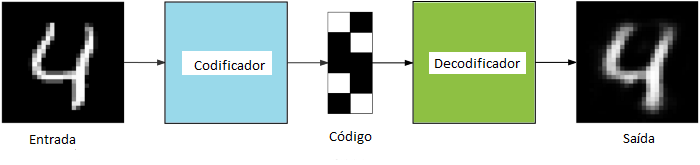

<center>Figura 2 - Esquema simplificado de um autoencoder.("AE_esquema.png")</center>

Para construir um autoencoder, precisamos de três elementos: 1) um método de codificação; 2) um método de decodificação; e 3) uma função de custo para comparar a saída prevista pelo modelo com a entrada e, assim, permitir o aprendizado por meio da minimização dessa função de custo.

Autoencoders consistem principalmente de um algoritmo de redução (ou compressão) de dimensionalidade com algumas propriedades importantes:

- Especificidade aos dados: os autoencoders só são capazes de compactar dados de maneira significativa quando as entradas forem semelhantes aos dados usados no treinamento. Como eles aprendem caracteríticas específicas dos dados de treinamento fornecidos, eles são diferentes de algoritmos de compactação de dados padrão, tal como, "jpeg" para imagens. Portanto, não podemos esperar que um autoencoder treinado em dígitos manuscritos seja capaz de compactar fotos de paisagens.


- Apresentam perdas: a saída do autoencoder não é exatamente igual à entrada, mas sim uma representação próxima degradada. Se for desejado compactação sem perdas, os autoencoders não podem ser usados.


- Treinamento não supervisionado: para treinar um autoencoder não é necessário nada muito complexo, basta apenas usar os dados de entrada como entrada e como saída. Os autoencoders são treinados usando aprendizagem não supervisionada, pois não precisam de rótulos explícitos para treinar. Para ser mais preciso, eles são auto supervisionados porque geram seus próprios rótulos a partir dos dados de treinamento.


Um autoencoder pode possuir qualquer tipo de camada, dependendo do tipo de dados e do problema que se deseja resolver. Em um autoencoder com camadas densas, tanto o codificador quanto o decodificador são redes neurais feedforward totalmente conectadas. O código (saída do codificador) consiste na saída de uma única camada da RNA com o número de neurônios de nossa escolha. O número de neurônios no código é um hiperparâmetro que é definido antes de treinar o autoencoder.

Na Figura 3 é mostrada uma arquitetura mais geral de um autoencoder com camadas densas. A entrada é processada pelo codificador, para produzir o código. O código é produzido no "gargalo" do autoencoder. O gargalo é a camada do autoencoder que possui o menor número de ativações e consiste na última camada do codificador. O decodificador, que tem uma estrutura semelhante ao codificador, gera a saída usando o código. O objetivo é obter uma saída idêntica à entrada. Observe que a arquitetura do decodificador é a imagem espelhada do codificador. Este não é um requisito, mas normalmente é o caso. O único requisito é a dimensionalidade da entrada e da saída que precisam ser a mesma.




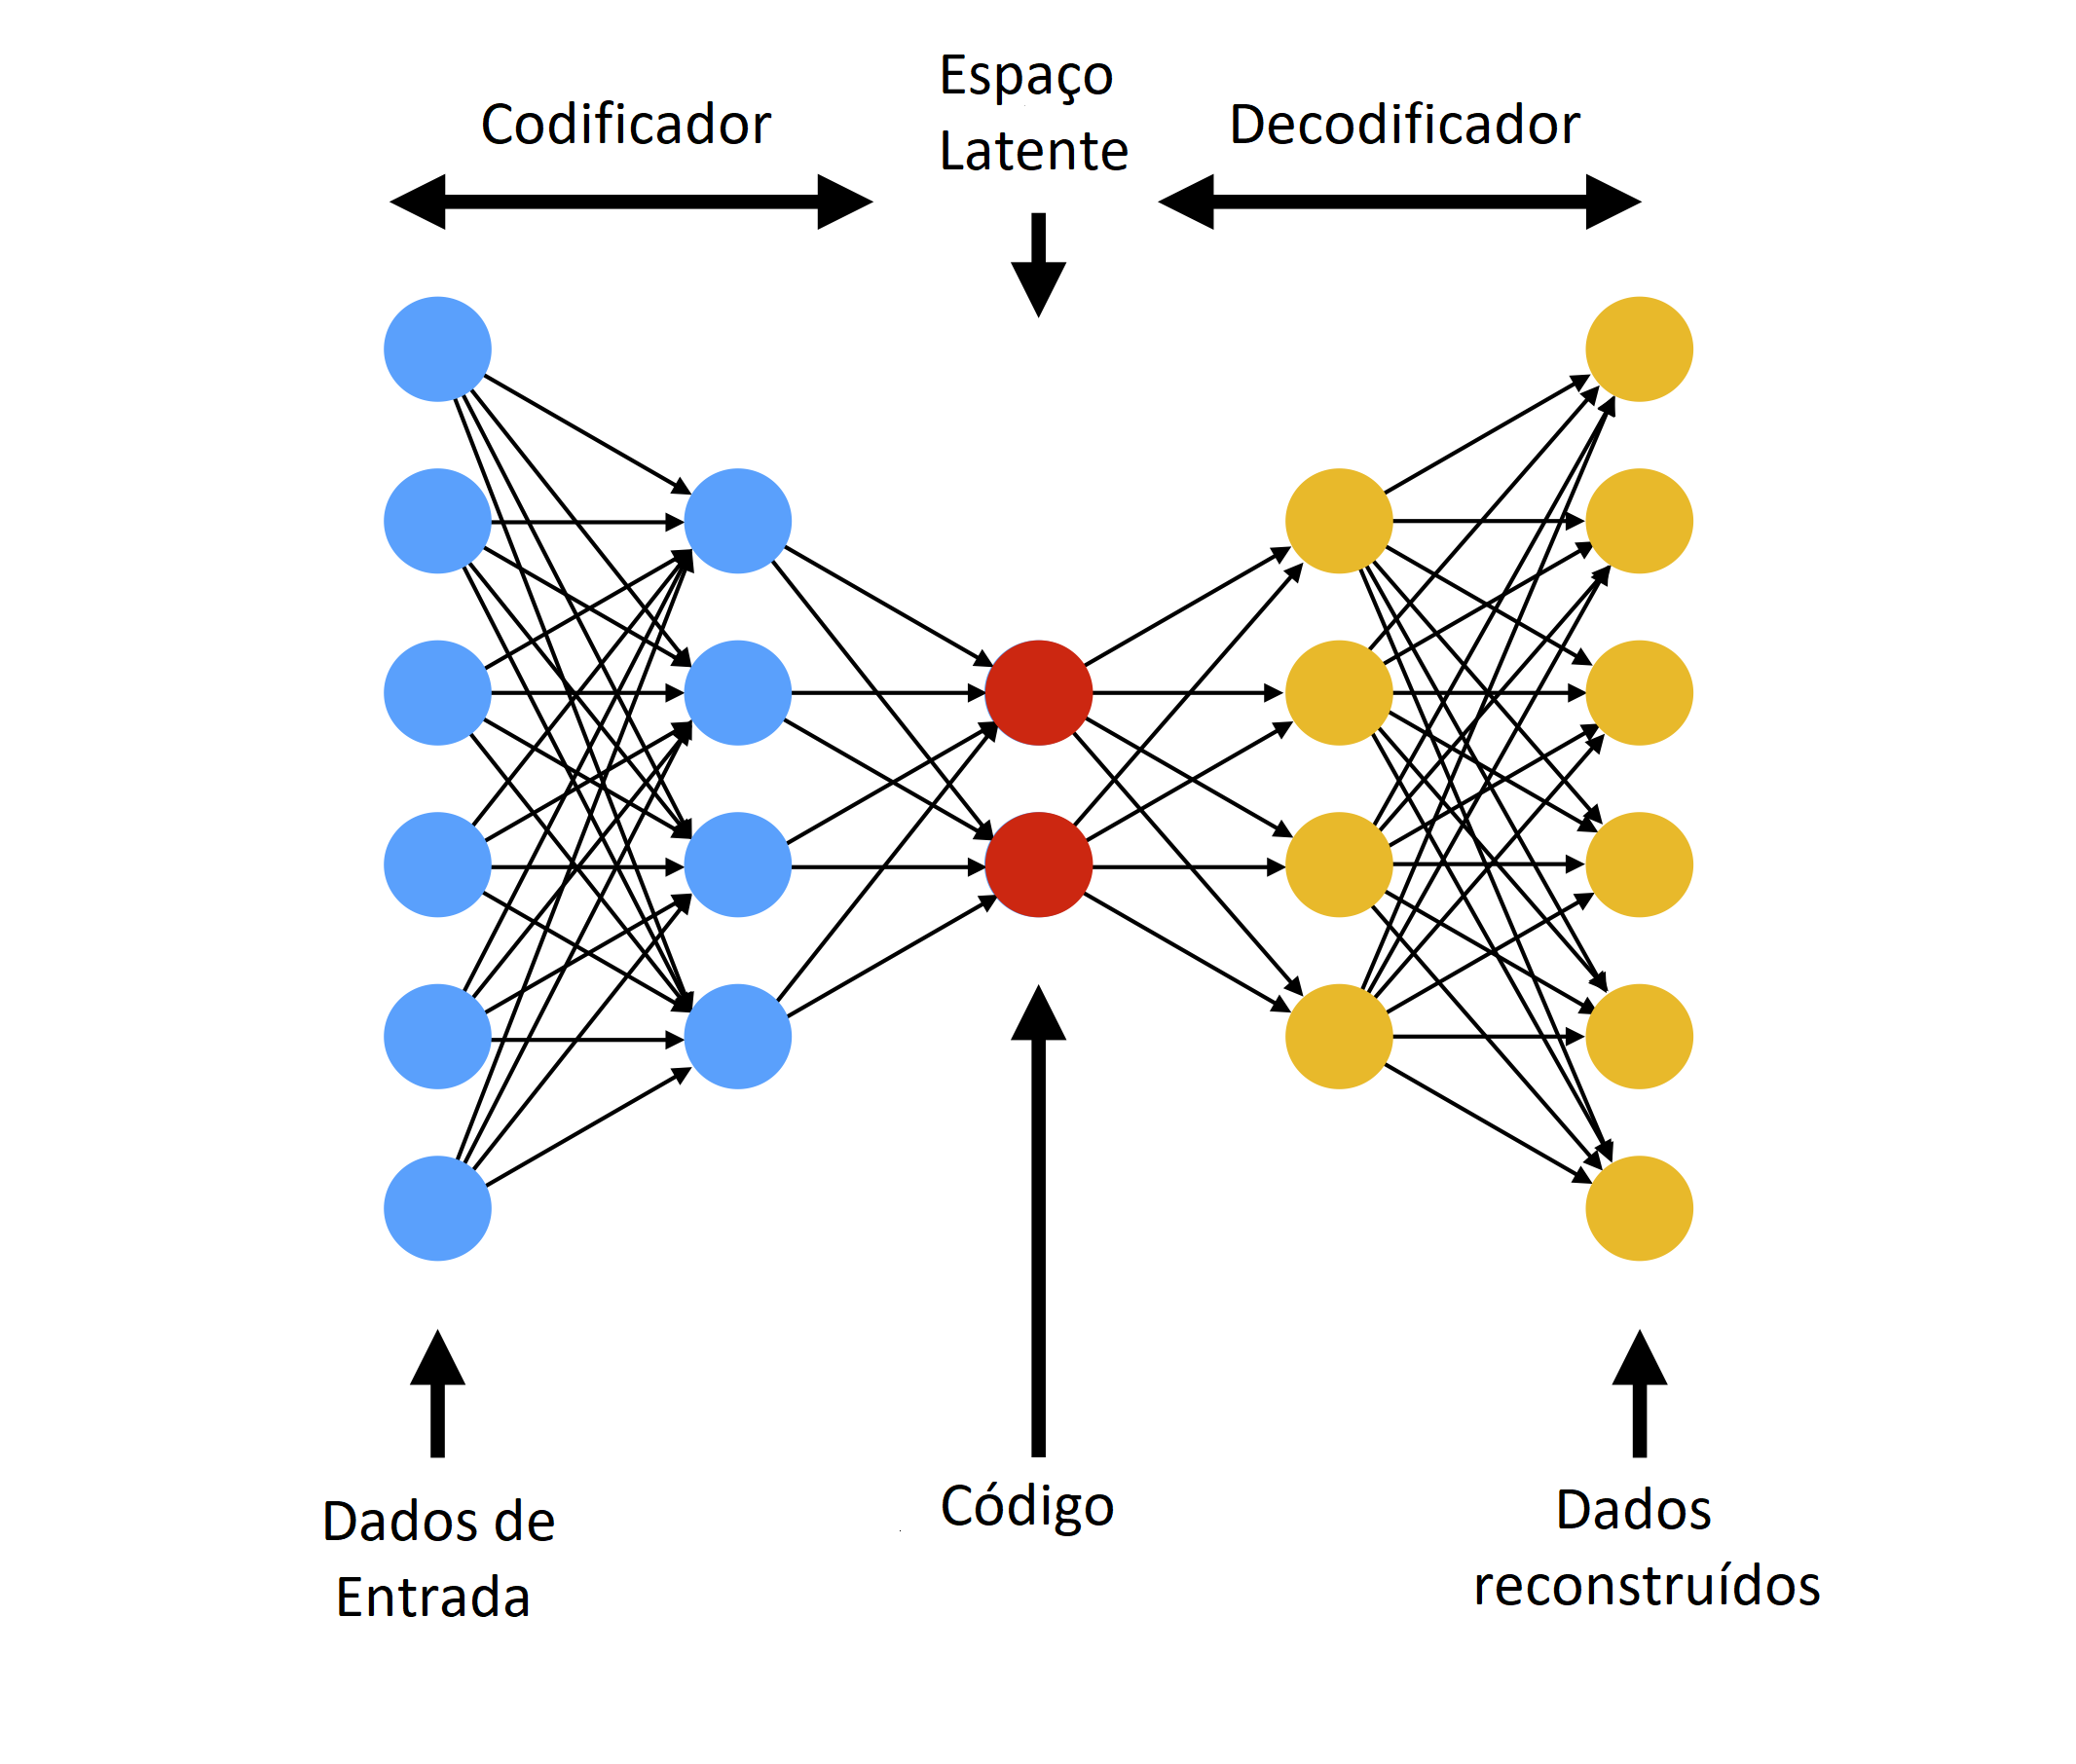

<center>Figura 3 - Esquema greal de um autoencoder.("AE_esquema_geral.png")center>

Existem quatro hiperparâmetros que precisam ser definidos antes de treinar um autoencoder:

- Dimensão do código: número de elementos da representação latente, quanto menor a dimensão, maior a compressão.
- Número de camadas: o autoencoder pode ter quantas camadas for desejado. Na Figura 3 acima, temos três camadas no codificador e duas no decodificador.
- Número de neurônios por camada: normalmente, os autoencoders parecem ser um “sandwitch”. O número de neurônios por camada diminui com cada camada subsequente do codificador e aumenta de volta no decodificador. Além disso, o decodificador é simétrico ao codificador em termos de estrutura de camadas. Conforme já observado, isso não é necessário e temos controle total sobre esses parâmetros.
- Função de custo: usamos o erro quadrático médio (mse) ou a entropia cruzada binária. Se os valores de entrada estiverem no intervalo [0, 1], normalmente usamos a entropia binária cruzada, caso contrário, usamos o erro quadrático médio.

### 4.4 Matemática dos autoencoders

A matemática por trás dos autoencoders é bastante simples e fácil de entender.

Como visto, dividimos o autoencoder em duas partes, o codificador e o decodificador.

- Codificador:  $\phi: X \to F$



- Decodificaor: $\psi: F \to X$

A função do codificador, denotado por $\phi$, é mapear os dados originais $X$, para um espaço latente $F$, que é gerado no "gargalo" do autoencoder. A função do decodificador, denotado por $\psi$, é mapear o espaço latente $F$ para a saída. A saída, neste caso, é igual à entrada. Assim, basicamente estamos tentando recriar os dados originais após ser realizada uma compressão não linear nos mesmos. Portanto, o objetivo de treinar um autoencoder é minimizar o erro entre a entrada e a saída reconstruída pelo decodificador. Esse objetivo pode ser expresso matematicamente por:

$$\phi, \psi = \min\limits_{\phi, \psi} {Erro[X - (\phi o \psi)(X)]}$$

onde $(\phi o \psi)$ representa a função implemenetada pelo autoencoder, que é composição do codificador e decodificador, e $Erro$ é uma determinada função de custo.

Tendo em vista que o treino de um autoencoder tem a mesma função do treino de qualquer RNA, então, os autoencoders são treinados da mesma maneira que as RANs via retropropagação.

## 5. Exemplo de autoencoder com camadas densas

Vamos implementar um autoencoder com camadas densas para reconstruir o conjunto de dígitos MNIST.

Como as imagens do conjunto de dígitos MNIST são pequenas e em tons de cinza, vamos processar as imagens de dígitos usando RNAs somente com camadas densas.

### 5.1 Carregar e processar dados

A célula abaixo carrega o conjunto de dados de dígitos MNIST da coleção do Keras.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Dimensão dos dados de entrada de treinamento =', x_train.shape)
print('Dimensão dos dados de entrada de teste =', x_test.shape)
print('Dimensão dos dados de saída de treinamento =', y_train.shape)
print('Dimensão dos dados de saída de teste =', y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dimensão dos dados de entrada de treinamento = (60000, 28, 28)
Dimensão dos dados de entrada de teste = (10000, 28, 28)
Dimensão dos dados de saída de treinamento = (60000,)
Dimensão dos dados de saída de teste = (10000,)


- Observa-se que as saídas não são usadas pelo autoencoder.

Vamos redimensionar as imagens para transformá-las em vetores.

In [ ]:
# Número total de pixels nas imagens
nx = x_train.shape[1]*x_train.shape[2]

# Redimensionamento e normalização das imagens
x_train_flat = np.reshape(x_train, (x_train.shape[0], nx))/255.
x_test_flat = np.reshape(x_test, (x_test.shape[0], nx))/255.

print('Dimensão dos dados de entrada de treinamento =', x_train_flat.shape)
print('Dimensão dos dados de entrada de teste =', x_test_flat.shape)

Dimensão dos dados de entrada de treinamento = (60000, 784)
Dimensão dos dados de entrada de teste = (10000, 784)


#### Gráficos de alguns exemplos

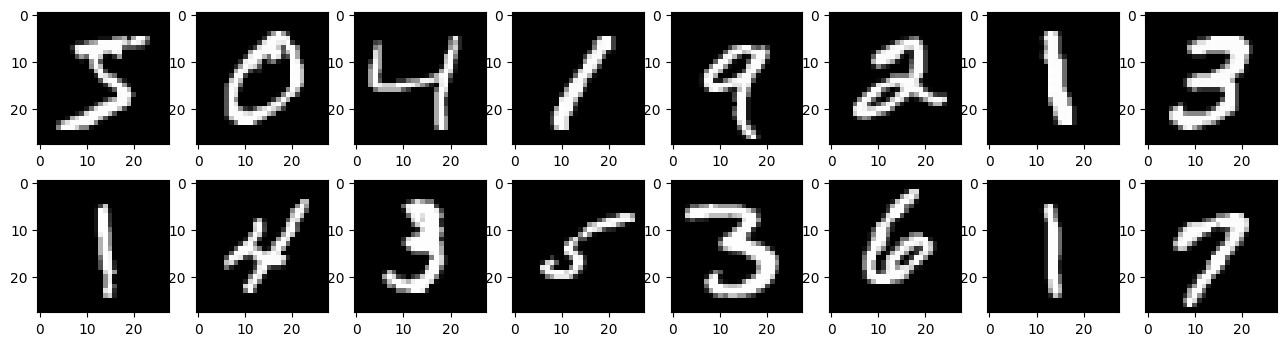

In [ ]:
fig, axs = plt.subplots(2, 8, figsize=(16, 4))
index = 0
for i in range(2):
    for j in range(8):
        axs[i,j].imshow(x_train[index], cmap='gray', vmin=0, vmax=255)
        index += 1
plt.show()

### 5.2 Configuração do autoencoder

Para esse autoencoder vamos usar três camadas densas no codificador e também no decodificador.

A configuração do autoencoder é realizada usando a classe sequencial do Keras.

Da mesma forma feita para o autoencoder simples, vamos criar separadamente o codificador e o decodificador para depois criar o autoencoder com a composição dos dois. Isso é feito para podermos utilizar o codificador e o decodificador separadamente após o treinamento para gerar o espaço latente e novos dados.

In [ ]:
# Importa classes e funções
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LayerNormalization, Input

# Define dimensões das camadas do autoencoder
input_size = 784 # (28*28)
hidden1_size = 128
hidden2_size = 64
code_size = 32

# Configura codificador
encoder = Sequential()
encoder.add(Input(shape=(input_size,)))
encoder.add(Dense(units=hidden1_size, activation='gelu'))
encoder.add(Dense(units=hidden2_size, activation='gelu'))
encoder.add(Dense(units=code_size, activation='gelu'))
encoder.add(LayerNormalization())

# Configura decodificador
decoder = Sequential()
decoder.add(Input(shape=(code_size,)))
decoder.add(Dense(units=hidden2_size, activation='gelu'))
decoder.add(Dense(units=hidden1_size, activation='gelu'))
decoder.add(Dense(units=input_size, activation='sigmoid'))

# Configura autoencoder
autoencoder = Sequential([encoder, decoder])

# Sumario do codificador
print('Codificador:')
print(encoder.summary(),'\n\n')

# Sumario do decodificador
print('Decodificador:')
print(decoder.summary(),'\n\n')

# Sumario do autoencoder
print('Autoencoder:')
print(autoencoder.summary())

Codificador:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,880 (433.12 KB)

 Trainable params: 110,880 (433.12 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 32)             │       110,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 784)            │       111,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,448 (868.94 KB)

 Trainable params: 222,448 (868.94 KB)

 Non-trainable params: 0 (0.00 B)

None


- Observe que todas as camadas densas usam a função de ativação `gelu` a menos da camada de saída do autoencoder que usa a ativação sigmóide porque precisamos que as saídas estejam entre [0, 1]. A entrada também está nesse intervalo.

- Foi incluída uma camada de normalização de exemplos na saída do codificador na tentativa de normalizar a sua saída, que consiste na representação latente dos dados, para valores em torno de zero.

- Na primeira camada do decodificador tem que definir a dimensão das entradas para podermos usá-lo separadamente do autoencoder.

### 5.3 Compilação do autoencoder

Vamos compilar o autoencoder com a seguinte configuração:

- Otimizador: Adam com taxa de aprendizado de 0.001;
- Função de custo: "binary cross entropy"
- Métrica: "binary accuracy"

Observa-se que como as saídas do autoencoder são os pixels das imagens normalizados entre 0 e 1, então, esse valores podem ser bem representados por uma probabilidade que possui valores entre 0 e 1. Em razão disso o uso da função de custo entropia cruzada binária é justificada e funciona melhor nesse caso do que o erro quadrático médio.

In [ ]:
# Define otimizador Adam
adam = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compilação do autoencoder
autoencoder.compile(optimizer=adam, loss='binary_crossentropy', metrics=['binary_accuracy', 'mae'])

### 5.4 Treinamento do autoencoder

Vamos treinar o autoencoder usando 30 épocas e lotes de 1024 elementos.

In [ ]:
results = autoencoder.fit(x_train_flat, x_train_flat, epochs=50, batch_size=1000, validation_data=(x_test_flat, x_test_flat))

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - binary_accuracy: 0.6853 - loss: 0.4925 - mae: 0.3297 - val_binary_accuracy: 0.7995 - val_loss: 0.2492 - val_mae: 0.1439
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - binary_accuracy: 0.8003 - loss: 0.2369 - mae: 0.1355 - val_binary_accuracy: 0.8011 - val_loss: 0.1919 - val_mae: 0.1056
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.8025 - loss: 0.1816 - mae: 0.0973 - val_binary_accuracy: 0.8040 - val_loss: 0.1575 - val_mae: 0.0809
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.8056 - loss: 0.1545 - mae: 0.0781 - val_binary_accuracy: 0.8067 - val_loss: 0.1429 - val_mae: 0.0698
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.8075 - loss: 0.1425 - mae: 0.0693 - val_binary_accuracy: 0.8068 - val_loss: 0.1347 - val_mae: 0.0651
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.8089 - loss: 0.1337 - mae: 0.0636 - val_binary_accuracy: 0.8090 - va

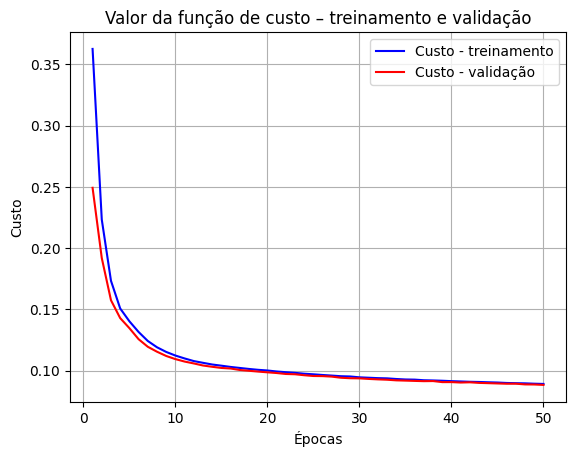

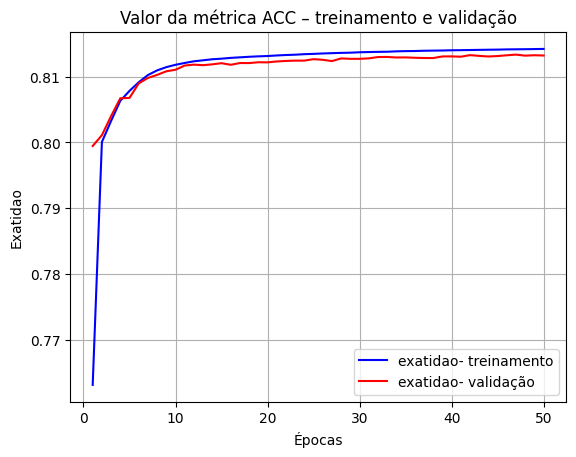

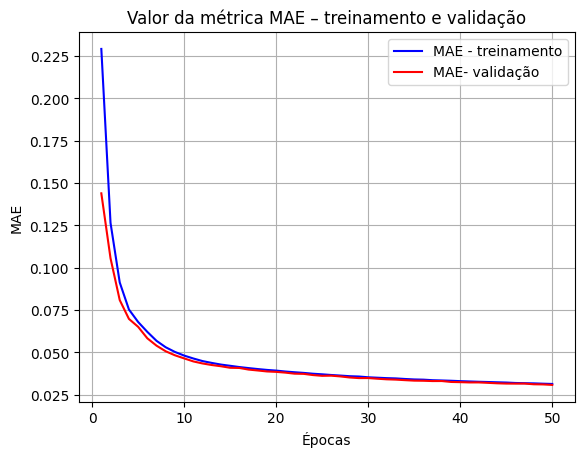

In [ ]:
def plot_train(history):
    history_dict = history.history

    # Salva custos, métricas em vetores
    custo = history_dict['loss']
    acc = history_dict['binary_accuracy']
    val_custo = history_dict['val_loss']
    val_acc = history_dict['val_binary_accuracy']
    mae = history_dict['mae']
    val_mae = history_dict['val_mae']

    # Cria vetor de épocas
    epocas = range(1, len(custo) + 1)

    # Gráfico dos valores de custo
    plt.plot(epocas, custo, 'b', label='Custo - treinamento')
    plt.plot(epocas, val_custo, 'r', label='Custo - validação')
    plt.title('Valor da função de custo – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('Custo')
    plt.legend()
    plt.grid()
    plt.show()

    # Gráfico dos valores da métrica exatidão
    plt.plot(epocas, acc, 'b', label='exatidao- treinamento')
    plt.plot(epocas, val_acc, 'r', label='exatidao- validação')
    plt.title('Valor da métrica ACC – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('Exatidao')
    plt.legend()
    plt.grid()
    plt.show()

    # Gráfico dos valores da métrica MAE
    plt.plot(epocas, mae, 'b', label='MAE - treinamento')
    plt.plot(epocas, val_mae, 'r', label='MAE- validação')
    plt.title('Valor da métrica MAE – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid()
    plt.show()

plot_train(results)

- Observa-se que não ocorre overfitting no treinamento.


### 5.5 Avaliação do autoencoder

Para avaliar o desempenho do autoencoder vamos calcular a função de custo e a métrica para os dados de treinamento e teste.

In [ ]:
# Calcula função de custo e métrica
autoencoder.evaluate(x_train_flat, x_train_flat)
autoencoder.evaluate(x_test_flat, x_test_flat)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - binary_accuracy: 0.8137 - loss: 0.0884 - mae: 0.0309
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - binary_accuracy: 0.8204 - loss: 0.0884 - mae: 0.0312


[0.08836980909109116, 0.8131930232048035, 0.030781878158450127]

-  Observa-se que a exatidão é da ordem de 81% tanto para os dados de treinamento como de teste. Esse resultado não é muito bom, mas tendo em vista a grande diversidade de imagens também não é muito ruim.

### 5.6 Espaço latente dos dígitos

Para poder reconstruir os dados a partir do espaço latente devemos obter os códigos que representam os dados no espaço latente de alguns dígitos 2 e 5.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Dimensão do espaço latente: (10000, 32)


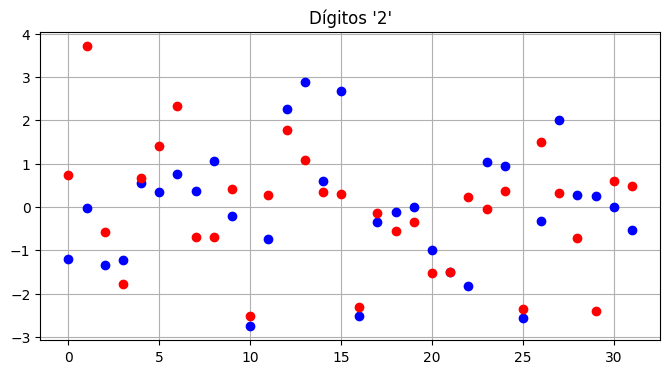

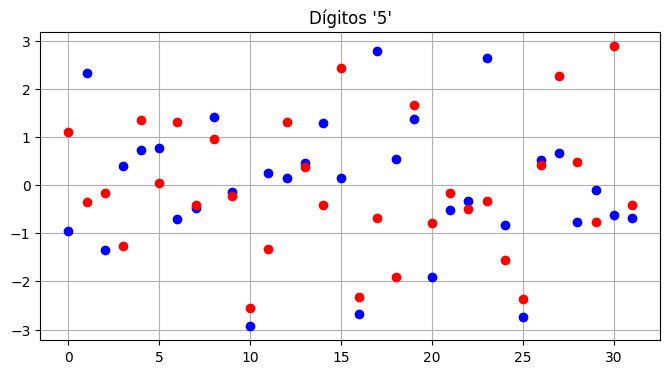

In [ ]:
# Calcula espaço latente (saída do codificador)
code = encoder.predict(x_test_flat)
print('Dimensão do espaço latente:', code.shape)

# Seleciona dígitos iguais a 2
ind2 = np.where((y_test == 2))

# Seleciona digitos iguais a 5
ind5 = np.where((y_test == 5))

# Gráfico dos códigos dos dígitos 2
plt.figure(figsize=(8,4))
plt.plot(code[ind2[0][0]], 'bo')
plt.plot(code[ind2[0][1]], 'ro')
plt.title("Dígitos '2'")
plt.grid()
plt.show()

# Gráfico dos códigos dos dígitos 5
plt.figure(figsize=(8,4))
plt.plot(code[ind5[0][0]], 'bo')
plt.plot(code[ind5[0][1]], 'ro')
plt.title("Dígitos '5'")
plt.grid()
plt.show()

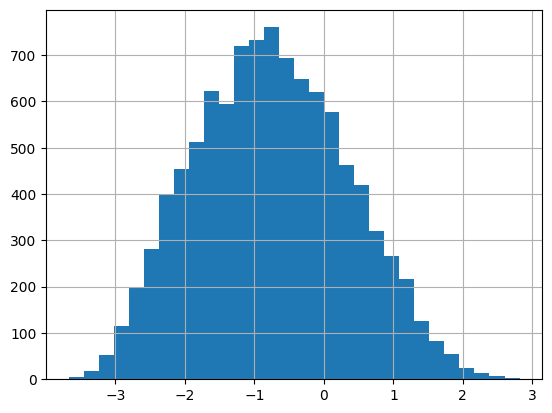

In [ ]:
plt.hist(code[:,2], bins=30)
plt.grid()
plt.show()

- Observa-se que não é possível analisar esses dados, pois eles somente tem algum significado para o decodificador.

### 5.7 Comparação das saídas previstas pelo autoencoder com as entradas

Para verificar visualmente o desempenho do autoencoder, vamos reconstruir algumas imagens de teste.

As saídas previstas pelo autoencoder representam como são reconstruídos os dados de entrada a partir da representação latente dos dados de entrada.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


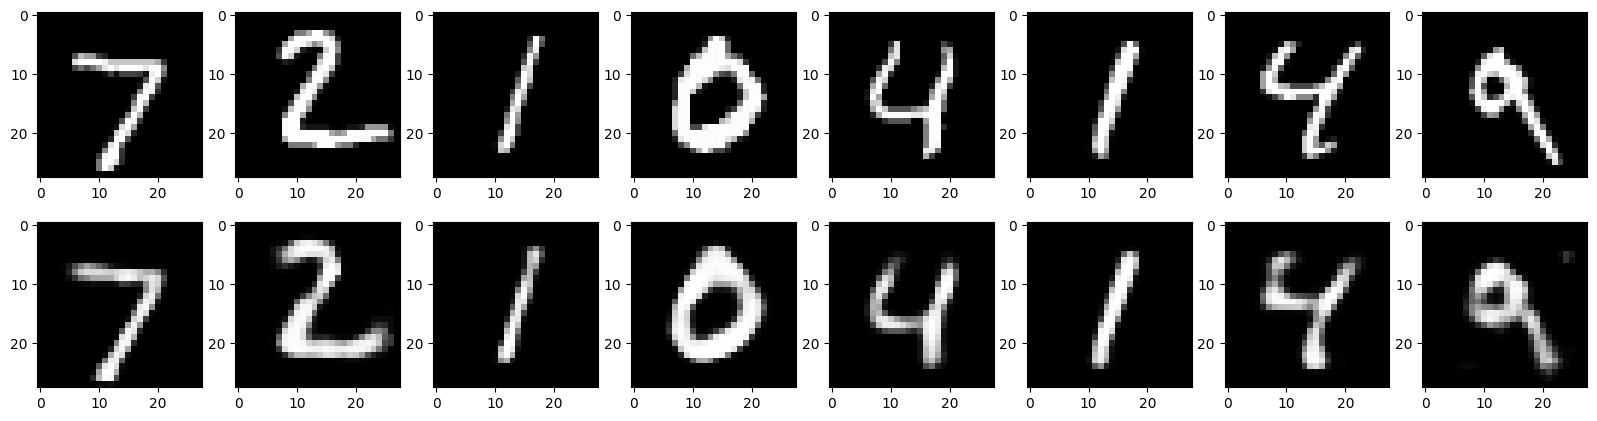

In [ ]:
# Calcula dados reconstriuídos pelo AE
x_prev = 255*decoder.predict(code)
x_prev = x_prev.astype(int)

# Mostra imagens originais e reconstruídas
f, pos = plt.subplots(2, 8, figsize=(20, 5))
for i in range(8):
    img_prev = np.reshape(x_prev[i], [28,28])
    pos[0,i].imshow(x_test[i], cmap='gray')
    pos[1,i].imshow(img_prev, cmap='gray')
plt.show()

- A primeira linha são as imagens originais e a segunda linha são as imagens reconstruídas.

- Observe que as imagens reconstruídas são muito semelhantes às originais, mas não são exatamente iguais.

- Como essa era uma tarefa simples, o autoencoder apresenta um desempenho muito bom.

### 5.8 Criação de novas imagens de dígitos

As representações latentes podem ser modificadas para criar novas imagens. As operações que podem ser realizadas no espaço latente com um autoencoder são as seguintes:

- Adição de ruído;
- Combinação linear de representações latentes de vários exemplos;
- Alteração da intensidade luminosa.


### Adição de ruído

Vamos adicionar um ruído à representação latente de um dígito e verificar como é alterada a imagem reconstruída com essa nova representação latente.

O ruído adicionado possui distribuição normal com média zero. Vamos testar diferentes desvios padrão para verificar a sua influência na nova imagem.

Média: -0.06759694
Desvio padrão: 1.3939456
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


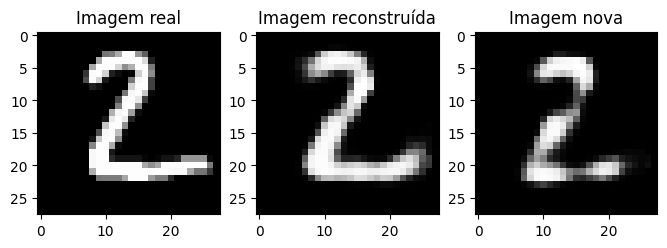

In [ ]:
"""Adição de ruído"""

# Trocar o valor de index para usar outras imagens
index = 1

# Seleciona código da imagem de número 2
codei = code[index]
codei = np.reshape(codei, [1,32,])

# Média e desvio padrão do código
print('Média:', np.mean(codei))
print('Desvio padrão:', np.std(codei))

# Reconstroi imagem original
img_prev = 255*decoder.predict(codei)
img_prev = img_prev.astype(int)
img_prev = np.reshape(img_prev, [28,28])

# Define desvio padrão do ruído
dvp = 0.7

# Cria nova imagem adicionando ruído gaussiano ao código
code_noise = codei + dvp*np.random.randn(1,32)
img_noise = 255*decoder.predict(code_noise)
img_noise = img_noise.astype(int)
img_noise = np.reshape(img_noise, [28,28])

# Mostra imagens de dígitos 2
f, pos = plt.subplots(1, 3, figsize=(8, 8))
pos[0].imshow(x_test[index], cmap='gray')
pos[0].set_title('Imagem real')
pos[1].imshow(img_prev, cmap='gray')
pos[1].set_title('Imagem reconstruída')
pos[2].imshow(img_noise, cmap='gray')
pos[2].set_title('Imagem nova')
plt.show()

- Obviamente, na medida em que o desvio padrão do ruído adicionado à representação latente aumenta, a nova imagem se torna mais diferente da original.


### Alteração da intensidade luminosa

Vamos alterar a amplitude da representação latente das imagens, multiplicando o código das imagens por uma constante e verificar o efeito que tem na nova imagem criada.

Observa-se que essa constante deve ter valor positivo.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


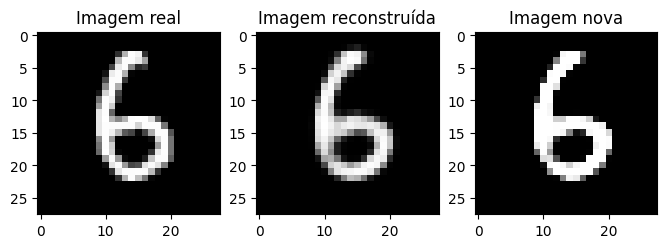

In [ ]:
"""Alteração da intensidade luminosa"""

# Trocar o valor de index para usar outras imagens
index = 21

# Seleciona código de um dígito 2
codei = code[index]
codei = np.reshape(codei, [1,32,])

# Reconstroi imagem original
img_prev = 255*decoder.predict(codei)
img_prev = img_prev.astype(int)
img_prev = np.reshape(img_prev, [28,28])

# Define fator para alteração da intensidade luminosa (f_lum = 1, não altera imagem original)
f_lum = 3.0

# Cria nova imagem adicionando ruído gaussiano ao código
code_amp = f_lum*codei
img_amp = 255*decoder.predict(code_amp)
img_amp = img_amp.astype(int)
img_amp = np.reshape(img_amp, [28,28])

# Mostra imagens de dígitos 2
f, pos = plt.subplots(1, 3, figsize=(8, 8))
pos[0].imshow(x_test[index], cmap='gray')
pos[0].set_title('Imagem real')
pos[1].imshow(img_prev, cmap='gray')
pos[1].set_title('Imagem reconstruída')
pos[2].imshow(img_amp, cmap='gray')
pos[2].set_title('Imagem nova')
plt.show()

- Observe que a alteração da amplitude dos valores da representação latente para essas imagens de dígitos tem o efeito de alterar o contraste da imagem.

### Combinação linear de duas imagens

Duas imagens podem ser combinadas para gerar um nova imagem.

Essa combinação é realizada pela combinação linear das representações latentes de duas ou mais imagens.

A nova imagem gerada pela combinação de duas representações latentes de dígitos diferentes é uma combinação dos dois dígitos e depende do peso de ponderação dado para cada código.

Vamos realizar uma operação que consiste na transição de um dígito para outro. Essa transição é realizada alterando linearmente os pesos dos códigos de cada imagem. Usaremos a seguinte equação para obter a representação latente da combinação dos dois dígitos:

$$code_{comb} = code_1 + (code_2 - code_1)*\alpha$$

onde $code_1$ e $code_2$ são as representações latentes de duas imagens, $code_{com}$ é a representação latente da combinação das duas imagens originais e $\alpha$ é um valor que varia linearmente entre 0 e 1.

Digito da imagem 1: 9
Digito da imagem 2: 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


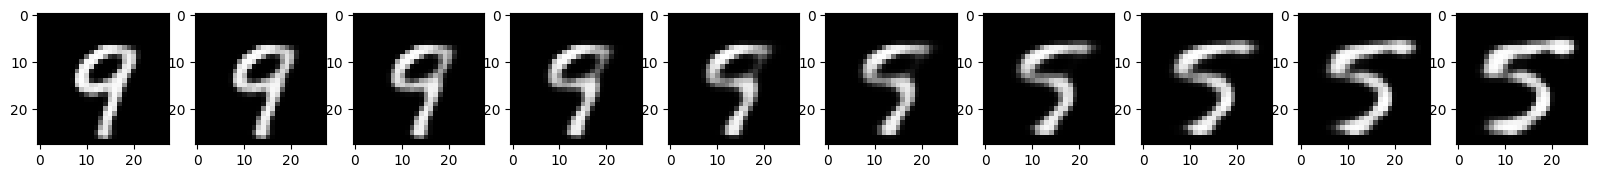

In [ ]:
"""Conbinação linear de dois dígitos diferentes"""

# Trocar os valores dos indexes para usar outras imagens
index1 = 12
index2 = 102

# Obtém os codigos das imagens selecionadas
code1 = code[index1]
code2 = code[index2]

# Classes de dígitos da imagens selecionadas
print('Digito da imagem 1:', y_test[index1])
print('Digito da imagem 2:', y_test[index2])

# Inclui eixo dos exemplos nos códigos
code1 = np.reshape(code1, [1,32,])
code2 = np.reshape(code2, [1,32,])

# Cria sequencia de 10 imagens transitando da imagem index1 para a imagem index2
f, pos = plt.subplots(1, 10, figsize=(20, 4))
for i in range(10):
    # Gera novo código pela combinação linear dos dois códigos
    code_comb = code1 + (code2 - code1)*i/9

    # Reconstroi imagem
    img_comb = 255*decoder.predict(code_comb)
    img_comb = img_comb.astype(int)
    img_comb = np.reshape(img_comb, [28,28])
    pos[i].imshow(img_comb, cmap='gray')
plt.show()

### 5.9 Análise dos resultados

Os resultados obtidos por esse autoencoder podem ser considerados muito bons, sendo que ele é capaz de reproduzir as imagens de entrada usando as suas representações latentes. Além disso, o autoencoder é capaz de criar nova imagens diferentes das originais usando transfromações no espaço latente.

Se for desejado, podemos melhorar o autoencoder aumentando o número de camadas e o número de neurônios, ou talvez usar camadas convolucionais.

Aumentar o número de parâmetros permite que o autoencoder aprenda codificações mais complexas. Porém, deve-se ter cuidado, pois um grande número de parâmetros pode causar sobreajuste dos dados de treinamento e, portanto, o autoencoder perderá a capacidade de generalização.

## 6. Autoencoder com camadas convolucionais

Como já vimos as camadas convolucionais são muito eficientes para extrair características de imagens, portanto, são também muito boas para criar imagens a partir de representações latente.

A arquitetura de um autoencoder com camadas convolucionais segue a mesma filosofia de um autoencoder com camadas densas, ou seja:

- O codificador do autoencoder deve reduzir a resolução da imagem enquanto aumenta o número de filtros.
- O decodificador deve aumentar a resolução da imagem enquanto diminui o número de filtros.
- A camada de saída do decodificador deve ter as mesmas dimensões da imagem original.

Na Figura 5 é apresentado um exemplo de um esquema de arquitetura de um autoencoder com camadas convolucionais. Esse esquema mostra um autoencoder configurado para processar as imagens do conjunto de dígitos MNIST.

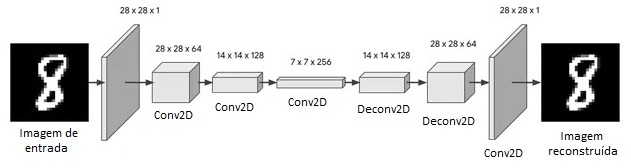


<center>Figura 5 - Esquema de um autoencoder convolucional aplicado às imagens do conjunto de dígitos MNIST.("AE_conv.jpg")</center>

Para exemplificar o uso de autoencoders com camadas convolucionais vamos usar o conjunto de dados CIFAR10, que contém 10 classes de imagens coloridas.

### 6.1 Carregar e processar dados

O conjunto de dados CIFAR1-10 pode ser carregado diretamente do Keras. Os comandos para carregar esse conjunto de dados pode ser visto no link https://www.tensorflow.org/api_docs/python/tf/keras/datasets/cifar10/load_data.

Características dos dados:

- As imagens são coloridas e estão no padrão RGB;
- Cada imagem tem dimensão de 32x32x3;
- O valor da intensidade luminosa de cada plano de cor é um número inteiro entre 0 e 255;
- As saídas representam o rótulo do objeto mostrado na imagem, sendo um número inteiro de 0 a 9.

In [ ]:
# Leitura do arquivo de dados
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = tf.keras.datasets.cifar10.load_data()

print("Dimensão x_train_orig:", x_train_orig.shape, "Dimensão y_train_orig:", y_train_orig.shape)
print("Dimensão x_test_orig:", x_test_orig.shape, "Dimensão y_test:", y_test_orig.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Dimensão x_train_orig: (50000, 32, 32, 3) Dimensão y_train_orig: (50000, 1)
Dimensão x_test_orig: (10000, 32, 32, 3) Dimensão y_test: (10000, 1)


Pela dimensão dos tensores com os dados de treinamento e teste temos:

- 50.000 imagens de treinamento com dimensão de 32x32x3 pixels;
- 10.000 imagens de teste com dimensão de 32x32x3 pixels.

Na célula abaixo é realizada a normalização dos pixels das imagens.

In [ ]:
# Guarda dimensão das imagens
image_dim = x_train_orig.shape[1:4]
print("Dimensão das imagens de entrada=", image_dim)

# Transformação dos dados em números reais entre 0 e 1
x_train = x_train_orig.astype('float32')/255.
x_test = x_test_orig.astype('float32')/255.

Dimensão das imagens de entrada= (32, 32, 3)


Vamos visualizar algumas imagens juntamente com as suas classes.

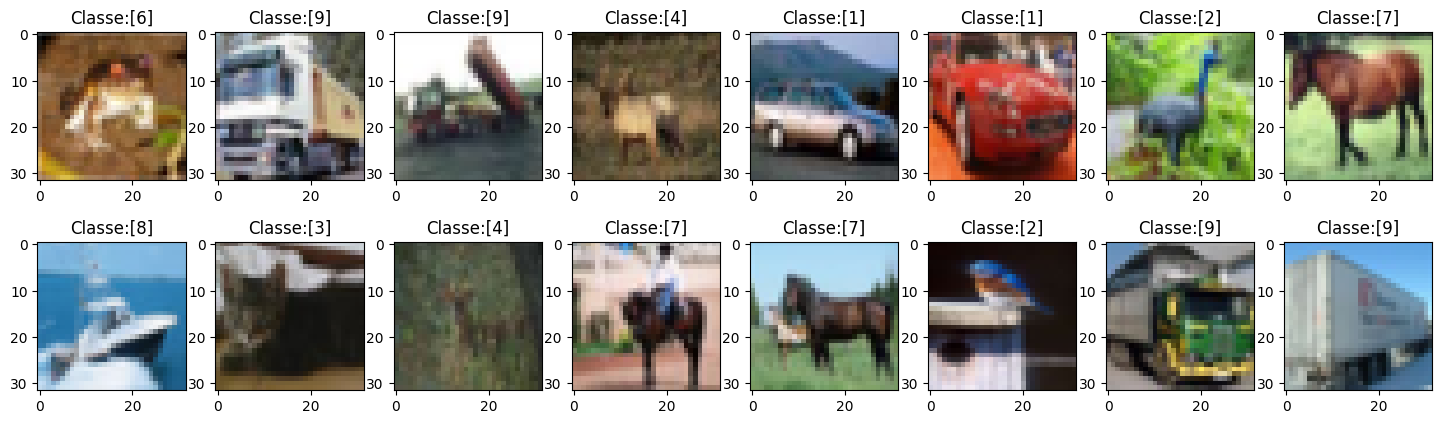

In [ ]:
fig, axs = plt.subplots(2, 8, figsize=(18, 5))
index = 0
for i in range(2):
    for j in range(8):
        axs[i,j].imshow(x_train[index], cmap='gray')
        axs[i,j].set_title('Classe:' + str(y_train_orig[index]))
        index += 1
plt.show()

### 6.2 Configuração do autoencoder

A arquitetura do codificador é a seguinte:

- Camada convolucional com 32 filtros, dimensão dos filtros=3x3, stride=2, função de ativação ReLu, padding=same;
- Camada convolucional com 48 filtros, dimensão dos filtros=3x3, stride=2, função de ativação ReLu, padding=same;
- Camada convolucional com 64 filtros, dimensão dos filtros=3x3, stride=2, função de ativação ReLu, padding=same;
- Camada de normalização de batelada.

A arquitetura do decodificador é a seguinte:

- Camada de deconvolução com 48 filtros, dimensão dos filtros=3x3, stride=2, função de ativação ReLu, padding=same;
- Camada de deconvolucão com 32 filtros, dimensão dos filtros=3x3, stride=2, função de ativação ReLu, padding=same
- Camada de deconvolucão com 16 filtros, dimensão dos filtros=3x3, stride=2, função de ativação ReLu, padding=same
- Camada convolucional com 3 filtros, dimensão dos filtros=1x1, stride=1, função de ativação sigmode, padding=same.

Observa-se que para os autoencoders convolucionais foi verificado que:

- É melhor utilizar stride=2 nas camadas convolucionais do que camadas de pooling. O efeito de redução das dimensões das imagens é o mesmo mas o desempenho final do autoencoder é melhor.

- Nas camadas do codificador é melhor usar função de ativação LeakyReLu e nas camadas do decodificar função de ativação ReLu.

In [ ]:
# Importa camadas necessárias
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, LayerNormalization, LeakyReLU, Input

# Configura codificador
encoder = Sequential()
encoder.add(Input(shape=image_dim))
encoder.add(Conv2D(32, kernel_size=3, strides=2, padding='same', activation=LeakyReLU()))
encoder.add(Conv2D(48, kernel_size=3, strides=2, padding='same', activation=LeakyReLU()))
encoder.add(Conv2D(64, kernel_size=3, strides=2, padding='same', activation=LeakyReLU()))
encoder.add(LayerNormalization())

# Configura decodificador
decoder = Sequential()
decoder.add(Input(shape=(4,4,64)))
decoder.add(Conv2DTranspose(48, kernel_size=3, strides=2, padding='same', activation='gelu'))
decoder.add(Conv2DTranspose(32, kernel_size=3, strides=2, padding='same', activation='gelu'))
decoder.add(Conv2DTranspose(16, kernel_size=3, strides=2, padding='same', activation='gelu'))
decoder.add(Conv2D(3, kernel_size=1, strides=1, padding='same', activation='sigmoid'))

# Configura autoencoder
autoencoder = Sequential([encoder, decoder])

# Sumario do codificador
print('Codificador:')
print(encoder.summary(),'\n\n')

# Sumario do decodificador
print('Decodificador:')
print(decoder.summary(),'\n\n')

# Sumario do autoencoder
print('Autoencoder:')
print(autoencoder.summary())

Codificador:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 48)       │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 4, 4, 64)       │           128 │
│ (LayerNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,608 (166.44 KB)

 Trainable params: 42,608 (166.44 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 4, 4, 64)       │        42,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 32, 32, 3)      │        46,227 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,835 (347.01 KB)

 Trainable params: 88,835 (347.01 KB)

 Non-trainable params: 0 (0.00 B)

None


- Observe que a função de ativação LeakyReLu é uma camada, assim, deve ser importada e usada como um objeto.

- A saída do codificar é um tensor de dimensão 4x4x64, que possui 1024 elementos. Note que as imagens originais com dimensão 32x32x3 possuem 3072 pixels, portanto, o espaço latente consiste de uma redução de 6 vezes em relação às imagens originais.

- Note que as possibilidades de configuração de um autoencoder são muitas e essa que foi escolhida é somente um exemplo.

### 6.3 Compilação do autoencoder

Vamos compilar o autoencoder com a seguinte configuração:

- Otimizador: Adam com taxa de aprendizado de 0.001;
- Função de custo: "binary cross entropy"
- Métrica: "mae"

Observa-se que como as saídas do autoencoder são os pixels das imagens normalizados entre 0 e 1, então, esse valores podem ser bem representados por uma probabilidade que possui valores entre 0 e 1.

A métrica erro absoluto médio é mais adequada para esse problema porque representa um erro médio entre os valores de pixels previstos e os reais das imagens.

In [ ]:
# Define otimizador Adam
adam = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compilação do autoencoder
autoencoder.compile(optimizer=adam, loss='binary_crossentropy', metrics=['mae'])

### 6.4 Treinamento do autoencoder

Vamos treinar o autoencoder usando 100 épocas e lotes de 500 elementos.

In [ ]:
results = autoencoder.fit(x_train, x_train, epochs=100, batch_size=500, validation_data=(x_test, x_test))

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - loss: 0.6455 - mae: 0.1607 - val_loss: 0.5769 - val_mae: 0.0781
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.5725 - mae: 0.0720 - val_loss: 0.5667 - val_mae: 0.0617
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.5651 - mae: 0.0604 - val_loss: 0.5631 - val_mae: 0.0551
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.5618 - mae: 0.0541 - val_loss: 0.5611 - val_mae: 0.0515
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.5593 - mae: 0.0498 - val_loss: 0.5595 - val_mae: 0.0475
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.5582 - mae: 0.0459 - val_loss: 0.5583 - val_mae: 0.0449
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.5599 - mae: 0.0513 - val_loss: 0.5572 - val_mae: 0.0420
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.5556 - mae: 0.0415 - val_loss: 0.5564 - val_mae: 0.0401
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━

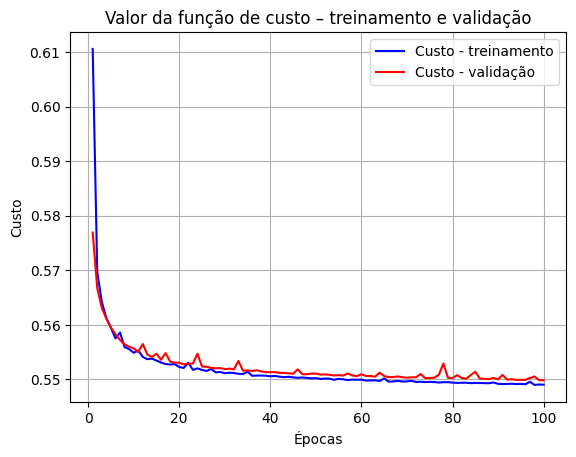

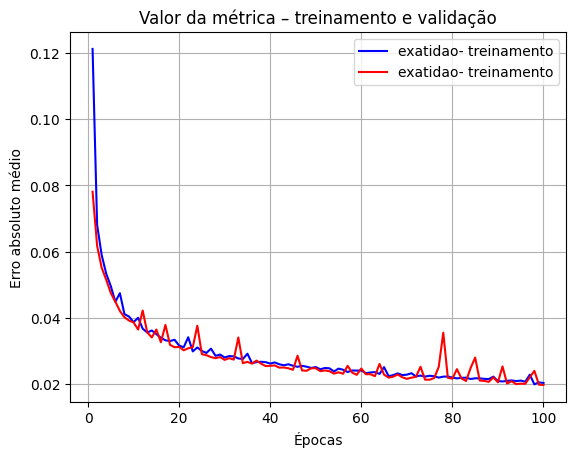

In [ ]:
def plot_train(history):
    history_dict = history.history

    # Salva custos, métricas e epocas em vetores
    custo = history_dict['loss']
    acc = history_dict['mae']
    val_custo = history_dict['val_loss']
    val_acc = history_dict['val_mae']

    # Cria vetor de épocas
    epocas = range(1, len(custo) + 1)

    # Gráfico dos valores de custo
    plt.plot(epocas, custo, 'b', label='Custo - treinamento')
    plt.plot(epocas, val_custo, 'r', label='Custo - validação')
    plt.title('Valor da função de custo – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('Custo')
    plt.legend()
    plt.grid()
    plt.show()

    # Gráfico dos valores da métrica
    plt.plot(epocas, acc, 'b', label='exatidao- treinamento')
    plt.plot(epocas, val_acc, 'r', label='exatidao- treinamento')
    plt.title('Valor da métrica – treinamento e validação')
    plt.xlabel('Épocas')
    plt.ylabel('Erro absoluto médio')
    plt.legend()
    plt.grid()
    plt.show()

plot_train(results)

### 6.5 Avaliação do autoencoder

Para avaliar o desempenho do autoencoder vamos calcular o valor da função de custo e da métrica.

In [ ]:
# Calcula função de custo e métrica
autoencoder.evaluate(x_train, x_train)
autoencoder.evaluate(x_test, x_test)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.5485 - mae: 0.0197
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5499 - mae: 0.0198


[0.5498384237289429, 0.019683020189404488]

-  Observa-se que o erro absoluto médio é da ordem de 0,02 tanto para os dados de treinamento como de teste. Esse resultado é bom, tendo em vista a complexidade das imagens e o fato do espaço latente ser 3 vezes menor do que as imagens originais.

- Note que se for desejado, provavelmente é possível obter resultados melhores aumentando o número de camadas e o número de filtros do autoencoder.


### 6.6 Espaço latente das imagens

O espaço latente de cada imagem é um tensor de dimensão 4x4x64, assim, ele pode ser visto como sendo composto por 64 imagens de dimensão 4x4.

Vamos visualizar a representação latente de algumas imagens.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Dimensão do espaço latente: (10000, 4, 4, 64)


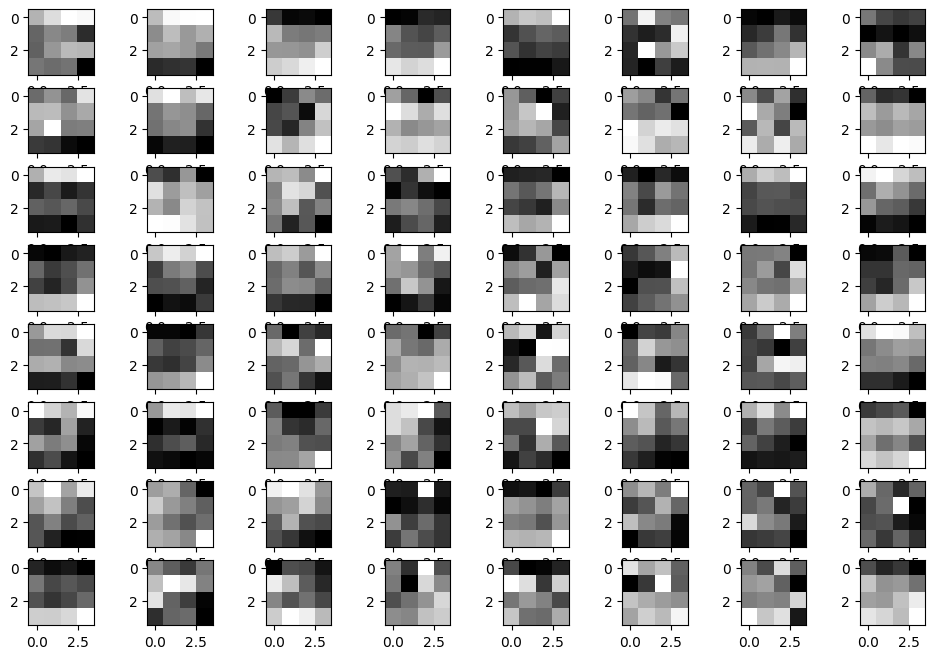

In [ ]:
# Calcula códigos das imagens de teste
code = encoder.predict(x_test)
print('Dimensão do espaço latente:', code.shape)

# Seleciona imagem do conjunto de teste
index = 2

# Mostra as 32 imagens
cont = 0
f, pos = plt.subplots(8, 8, figsize=(12, 8))
for i in range(8):
    for j in range(8):
        pos[i,j].imshow(code[index,:,:,cont], cmap='gray')
        cont += 1
plt.show()

- Obviamente não é possível analisar esses dados, pois eles somente tem algum significado para o decodificador.

- Observa-se que cada imagem de dimensão 4x4 do espaço latente representa a presença (pixel mais claro) ou não (pixel mais escuro) de uma determinada característica em 16 regiões diferentes das imagens.

### 6.7 Comparação das saídas previstas pelo autoencoder com as entradas

As saídas previstas pelo autoencoder representam como são reconstruídos os dados de entrada a partir da representação latente dos dados de entrada.

Vamos reconstruir as primeras 10 imagens de teste a partir das representações latentes calculadas no item anterior e visualizá-las junto com as imagens originais.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


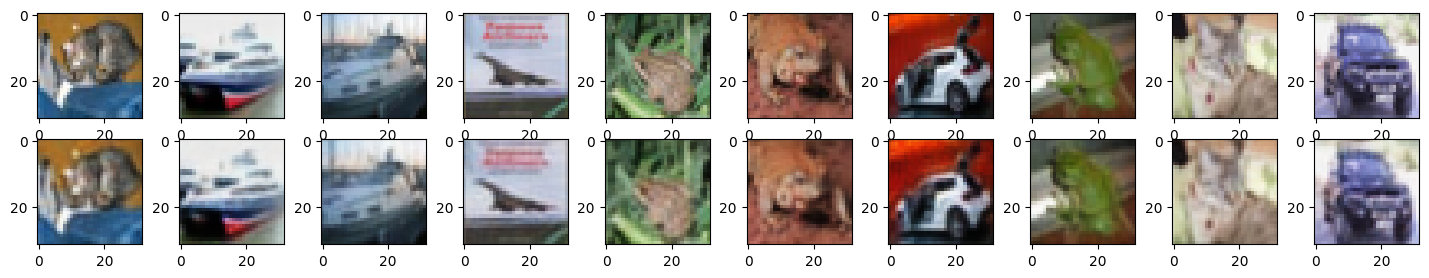

In [ ]:
# Reconstrução das imagens usando o espaço latente e o decodificador
x_prev = 255*decoder.predict(code)
x_prev = x_prev.astype(int)

# Mostra imagens originais e reconstruídas
f, pos = plt.subplots(2, 10, figsize=(18, 3))
for i in range(10):
    img_prev = np.reshape(x_prev[i], image_dim)
    pos[0,i].imshow(x_test[i], cmap='gray')
    pos[1,i].imshow(img_prev, cmap='gray')
plt.show()

- Observe que as imagens reconstruídas são muito semelhantes às originais.

- Pode-se concluir que o autoencoder apresenta um desempenho muito bom mesmo com a grande compactação existente entre a imagem original e a sua representação latente.

O erro médio porcentual entre as imagens reconstruídas e as originais é calculado na célula abaixo para termos uma ideía da sua grandeza

In [ ]:
# Erro médio absoluto
erro = np.mean(np.abs(x_test-x_prev/255.))
erro_per = 100*erro/np.mean(x_test)
print('Erro médio porcentual:', erro_per,'%')

Erro médio porcentual: 4.202591746200796 %


### 6.8 Criação de novas imagens

Com visto, as representações latentes podem ser modificadas para criar novas imagens.

Vamos criar novas imagens usando as mesmas transformações aplicadas nas representações latentes dos dígitos MNIST realizada anteriormente, ou seja:

1. Adição de ruído gaussiano com média zero na representação latente;
2. Alteração da amplitude da representação latente;
3. Combinação da representação latente de duas imagens.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Média: -0.0002087797
Desvio padrão: 1.0252326
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


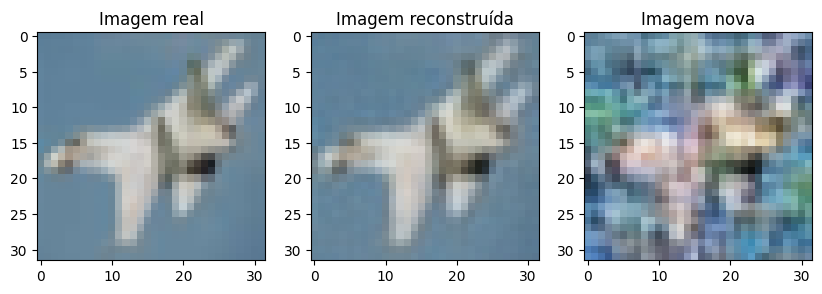

In [ ]:
"""Adição de ruído"""

# Trocar o valor de index para mostrar outras imagens
index = 10

# Seleciona código
codeI = code[index]

# Insere eixo dos exemplos
codeI = np.expand_dims(codeI, axis=0)

# Reconstroi imagem original
img_prev = 255*decoder.predict(codeI)
img_prev = img_prev.astype(int)

# Cálculo da média e desvio padrão dos códigos
print('Média:', np.mean(codeI))
print('Desvio padrão:', np.std(codeI))

# Desvio padrão do ruído
dvp = 0.2

# Cria nova imagem adicionando ruído gaussiano ao código
code_noise = codeI + dvp*np.random.randn(1,4,4,64)
img_noise = 255*decoder.predict(code_noise)
img_noise = img_noise.astype(int)

# Mostra imagens de dígitos 2
f, pos = plt.subplots(1, 3, figsize=(10, 4))
pos[0].imshow(x_test[index])
pos[0].set_title('Imagem real')
pos[1].imshow(img_prev[0])
pos[1].set_title('Imagem reconstruída')
pos[2].imshow(img_noise[0])
pos[2].set_title('Imagem nova')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


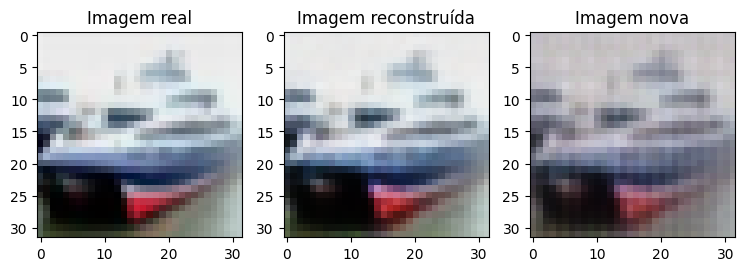

In [ ]:
"""Alteração de intensidade"""

# Trocar o valor de index para mostrar outras imagens
index = 1

# Seleciona código
codeI = code[index]

# Insere eixo dos exemplos
codeI = np.expand_dims(codeI, axis=0)

# Reconstroi imagem original
img_prev = 255*decoder.predict(codeI)
img_prev = img_prev.astype(int)

# Fator de alteração
f_lum = 0.7

# Cria nova representação latente alterando amplitude
code_amp = f_lum*codeI
img_amp = 255*decoder.predict(code_amp)
img_amp = img_amp.astype(int)

# Mostra imagens de dígitos 2
f, pos = plt.subplots(1, 3, figsize=(9, 3))
pos[0].imshow(x_test[index])
pos[0].set_title('Imagem real')
pos[1].imshow(img_prev[0])
pos[1].set_title('Imagem reconstruída')
pos[2].imshow(img_amp[0])
pos[2].set_title('Imagem nova')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


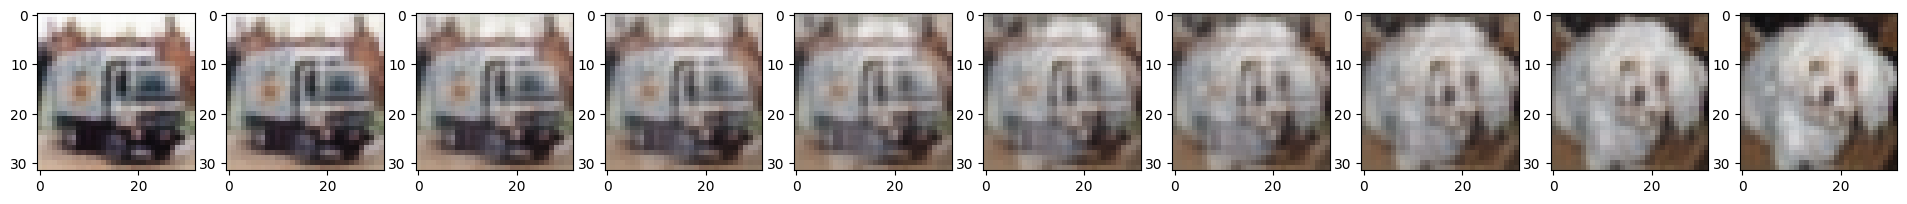

In [ ]:
"""Conbinação linear de duas images diferentes"""

# Trocar o valor de index para usar outras imagens
index1 = 11
index2 = 1000

# Obter os códigos das imagens selecionadas
code1 = code[index1]
code2 = code[index2]

# Gera imagens de transição da imagem 1 para a imagem 2
f, pos = plt.subplots(1, 10, figsize=(24, 3))
for i in range(10):
    # Gera novo código
    codei = code1 + (code2 - code1)*i/9

    # Inclui eixo dos exemplos
    codei = np.expand_dims(codei, axis=0)

    # Reconstroi imagem
    imgi = 255*decoder.predict(codei)
    imgi = imgi.astype(int)
    pos[i].imshow(imgi[0])
plt.show()

### 6.9 Análise dos resultados

Podemos conluir que um autoencoder é uma ferramenta poderosa para comprimir imagens.

Porém a geração de novas imagens por um autoencoder é limitada, consistindo basicamente de misturar imagens utlizadas no treinamento.